Matplotlib global setup for quantumarticle completed.


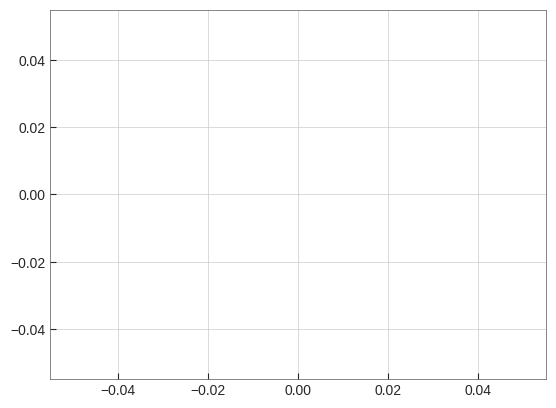

In [1]:
import numpy             as     np
import matplotlib        as     mpl
import matplotlib.pyplot as     plt
from   matplotlib        import rc
from   cycler            import cycler
import pickle

_widths = {
    # a4paper columnwidth = 426.79135 pt = 5.93 in
    # letterpaper columnwidth = 443.57848 pt = 6.16 in
    'onecolumn': {
        'a4paper' : 5.93,
        'letterpaper' : 6.16
    },
    # a4paper columnwidth = 231.84843 pt = 3.22 in
    # letterpaper columnwidth = 240.24199 pt = 3.34 in
    'twocolumn': {
        'a4paper' : 3.22,
        'letterpaper' : 3.34
    }
}

_wide_widths = {
    # a4paper wide columnwidth = 426.79135 pt = 5.93 in
    # letterpaper wide columnwidth = 443.57848 pt = 6.16 in
    'onecolumn': {
        'a4paper' : 5.93,
        'letterpaper' : 6.16
    },
    # a4paper wide linewidth = 483.69687 pt = 6.72 in
    # letterpaper wide linewidth = 500.48400 pt = 6.95 in
    'twocolumn': {
        'a4paper' : 6.72,
        'letterpaper' : 6.95
    }
}

_fontsizes = {
    10 : {
        'tiny' : 5,
        'scriptsize' : 7,
        'footnotesize' : 8, 
        'titlesize' : 10,
        'small' : 9, 
        'normalsize' : 10,
        'large' : 12, 
        'Large' : 14, 
        'LARGE' : 17,
        'huge' : 20,
        'Huge' : 25
    },
    11 : {
        'tiny' : 6,
        'scriptsize' : 8,
        'footnotesize' : 9, 
        'titlesize' : 10,
        'small' : 10, 
        'normalsize' : 11,
        'large' : 12, 
        'Large' : 14, 
        'LARGE' : 17,
        'huge' :  20,
        'Huge' :  25
    },
    12 : {
        'tiny' : 6,
        'scriptsize' : 8,
        'footnotesize' : 10,
        'titlesize' : 10, 
        'small' : 11, 
        'normalsize' : 12,
        'large' : 14, 
        'Large' : 17, 
        'LARGE' : 20,
        'huge' :  25,
        'Huge' :  25
    }
}

_width         = 1
_wide_width    = 1
_quantumviolet = '#53257F'
_quantumgray   = '#555555'

# Sets up the plot with the fitting arguments so that the font sizes of the plot
# and the font sizes of the document are well aligned
#
#     columns : string = ('onecolumn' | 'twocolumn')
#         the columns you used to set up your quantumarticle, 
#         defaults to 'twocolumn'
#
#     paper : string = ('a4paper' | 'letterpaper')
#         the paper size you used to set up your quantumarticle,
#         defaults to 'a4paper'
#
#     fontsize : int = (10 | 11 | 12)
#         the fontsize you used to set up your quantumarticle as int
#
#     (returns) : dict
#         parameters that can be used for plot adjustments

def global_setup(columns = 'twocolumn', paper = 'a4paper', fontsize = 10):
    plt.rcdefaults()
        
    # Seaborn white is a good base style
    plt.style.use(['seaborn-v0_8-whitegrid', './quantum-plots.mplstyle'])
    
    try:        
        # This hackery is necessary so that jupyther shows the plots
        mpl.use("pgf")
        %matplotlib inline
        plt.plot()
        mpl.use("pgf")
    except:
        print('Call to matplotlib.use had no effect')
        
    mpl.interactive(False)
    
    # Now prepare the styling that depends on the settings of the document
    
    global _width 
    _width = _widths[columns][paper]
    
    global _wide_width 
    _wide_width = _wide_widths[columns][paper]
    
    # Use the default fontsize scaling of LaTeX
    global _fontsizes
    fontsizes = _fontsizes[fontsize]
    
    plt.rcParams['axes.labelsize'] = fontsizes['small']
    plt.rcParams['axes.titlesize'] = fontsizes['large']
    plt.rcParams['xtick.labelsize'] = fontsizes['footnotesize']
    plt.rcParams['ytick.labelsize'] = fontsizes['footnotesize']
    plt.rcParams['font.size'] = fontsizes['small']
    plt.rcParams['figure.titlesize'] = fontsizes['small']
    
    return {
            'fontsizes' : fontsizes,
            'colors' : {
                'quantumviolet' : _quantumviolet,
                'quantumgray' : _quantumgray
            }
        }
    

# Sets up the plot with the fitting arguments so that the font sizes of the plot
# and the font sizes of the document are well aligned
#
#     aspect_ratio : float
#         the aspect ratio (width/height) of your plot
#         defaults to the golden ratio
#
#     width_ratio : float in [0, 1]
#         the width of your plot when you insert it into the document, e.g.
#         .8 of the regular width
#         defaults to 1.0
#
#     wide : bool 
#         indicates if the figures spans two columns in twocolumn mode, i.e.
#         when the figure* environment is used, has no effect in onecolumn mode 
#         defaults to False
#
#     (returns) : matplotlib figure object
#         the initialized figure object

def plot_setup(aspect_ratio = 1/1.62, width_ratio = 1.0, wide = False):
    width = (_wide_width if wide else _width) * width_ratio
    height = width * aspect_ratio
           
    return plt.figure(figsize=(width,height), dpi=120, facecolor='white')
    
global_setup()
print("Matplotlib global setup for quantumarticle completed.")

In [2]:
from dataclasses import dataclass
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.animation as animation
from matplotlib.colors import Normalize
from matplotlib.patches import Polygon, Patch
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, LogLocator, NullFormatter
from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter, uniform_filter1d
from scipy.interpolate import griddata


# Parameters for plotting
base_decoder_colors = {
    'uf': [
        "#6baed6", "#4292c6", "#3182bd", "#1f77b4", "#2171b5",
        "#08519c", "#08306b", "#08519c", "#08306b", "#08306b",
    ],
    'clayg': [
        "#fdae6b", "#ffbb78", "#ff8c00", "#fd8d3c", "#ffa726",
        "#f16913", "#ff7f0e", "#d95f02", "#d94801", "#a63603",
    ],
    'sl_clayg': [
        "#31a354", "#74c476", "#238b45", "#31a354", "#74c476",
        "#006d2c", "#00441b", "#006d2c", "#00441b", "#006d2c",
    ],
    'other': [
        "#e377c2", "#d62728", "#ff9896", "#c51b7d", "#8c564b",
        "#e377c2", "#d62728", "#ff9896", "#c51b7d", "#8c564b",
    ]
}

def parse_decoder_descriptor(decoder: str) -> dict:
    m = re.match(
        r'^(?P<base>uf|clayg|sl_clayg)'
        r'(?P<rest>.*)$',
        decoder
    )
    if not m:
        return {
            "base": None,
            "stop": None,
            "numeric_args": [],
            "growth_policy": None,
            "raw": decoder,
        }

    base = m.group("base")
    rest = m.group("rest")

    stop_match = re.search(r'_(no_stop_early|stop_early)', rest)
    stop = stop_match.group(1) if stop_match else None

    growth_policy = None
    growth_match = re.search(r'_custom_growth_(.+)$', rest)
    if growth_match:
        growth_policy = growth_match.group(1)

    numeric_args = re.findall(
        r'_(lifetime|cluster_lifetime|growth_rounds)_([0-9.]+)',
        rest
    )

    return {
        "base": base,
        "stop": stop,
        "numeric_args": numeric_args,
        "growth_policy": growth_policy,
        "raw": decoder,
    }

def decoder_colors(decoder, shift=True):
    parts = parse_decoder_descriptor(decoder)
    base = parts["base"]
    stop_early = parts["stop"]
    lifetime = None
    for arg, val in parts["numeric_args"]:
        if arg in ("lifetime", "cluster_lifetime"):
            lifetime = val
            break

    if not base:
        return base_decoder_colors['other']
    colors = base_decoder_colors.get(base, base_decoder_colors['other'])

    if shift and stop_early == 'stop_early':
        def shift(hex_color, factor=0.05):
            hex_color = hex_color.lstrip('#')
            rgb = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
            dark_rgb = tuple(int(c * factor) for c in rgb)
            return '#{:02x}{:02x}{:02x}'.format(*dark_rgb)
        colors = [shift(c) for c in colors]

    if shift and lifetime:
        factor = float(lifetime)
        def lighten(hex_color, factor=1.3):
            hex_color = hex_color.lstrip('#')
            rgb = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
            light_rgb = tuple(min(int(c * factor), 255) for c in rgb)
            return '#{:02x}{:02x}{:02x}'.format(*light_rgb)
        colors = [lighten(c, factor=0.15*factor) for c in colors]

    return colors

base_decoder_names = {
    'uf': 'UF',
    'clayg': 'CAYG',
    'sl_clayg': 'Single Layer CAYG',
}

def decoder_name(decoder, say_early=False, include_growth_policy=False, included_arguments={'l': lambda x: int(float(x))}):
    parts = parse_decoder_descriptor(decoder)
    base = parts["base"]
    stop = parts["stop"]
    numeric_args = parts["numeric_args"]
    growth_policy = parts["growth_policy"]

    if not base:
        return decoder

    name = base_decoder_names.get(base, base)

    argument_shorthands = {
        'lifetime': 'l',
        'cluster_lifetime': 'l',
        'growth_rounds': 'g',
    }

    num_args = []
    for arg, val in numeric_args:
        shown_arg = argument_shorthands.get(arg, arg)
        if included_arguments and shown_arg not in included_arguments:
            continue
        val = included_arguments[shown_arg](val)
        num_args.append(f"{shown_arg}={val}")

    if include_growth_policy and growth_policy:
        num_args.append(f"growth_policy={growth_policy}")

    if num_args:
        name += "(" + ", ".join(num_args) + ")"

    if stop and say_early:
        name += f" ({stop})"

    return name

def noise_model_name(noise_model):
    parts = noise_model.split('_')
    if len(parts) != 4:
        return noise_model
    _,_,_, meas_param = parts
    return fr'$p_{{\mathrm{{data}}}}=p$, $p_{{\mathrm{{meas}}}}={meas_param}p$'

In [3]:
import os
import re
import numpy as np
import pandas as pd

@dataclass
class Data:
    results: pd.DataFrame
    steps: pd.DataFrame
    idling: pd.DataFrame
    
    def to_pickle(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self, f)
            
def attach_np(results_df):
    """Add an Np column from the 1/N = 0 rows.

    Called after the results groupby has pooled the shards, so n on the baseline
    rows is already the summed N_p across all tasks.  Joins on p as well as
    (decoder, distance, rounds, noise_model), because N_p varies along the p
    sweep in split_p_steps mode.
    """
    if results_df.empty:
        return results_df

    keys = ["decoder", "distance", "rounds", "noise_model", "p"]
    base = (
        results_df[results_df["N"].isna()][keys + ["n"]]
        .rename(columns={"n": "Np"})
        .drop_duplicates(subset=keys)
    )
    out = results_df.merge(base, on=keys, how="left")

    idl = out[out["N"].notna() & out["Np"].notna()]
    if len(idl):
        nidl = idl["n"].to_numpy(float) / idl["Np"].to_numpy(float)
        bad = ~np.isclose(nidl, np.round(nidl), rtol=1e-6)
        if bad.any():
            print(f"  !! N_idl = n/Np is non-integer on {bad.sum()} rows "
                  f"({nidl[bad].min():.2f} .. {nidl[bad].max():.2f})")
            print(f"     Baseline and idling rows disagree -- a task may have "
                  f"written one but not the other.")
        print(f"  N_idl = {np.round(nidl).min():.0f} .. {np.round(nidl).max():.0f}")
        print(f"  N_p   = {out['Np'].min():.0f} .. {out['Np'].max():.0f}")

    miss = out["Np"].isna() & out["N"].notna()
    if miss.any():
        print(f"  !! {miss.sum()} idling rows have no 1/N=0 partner at the same p; "
              f"Np is NaN there")

    return out


def check_coverage(results_df, p_min, p_max, runs_p_min, runs_p_max, exponent=1.5,
                   tol=0.01):
    """Verify N_p matches the budget the generator scheduled for each p, 
    ie whether tasks failed on the cluster/ran twice.
    
    Returns a DataFrame of the baseline rows with Np_expected and ratio columns."""
    
    if results_df.empty:
        print("  (empty results)")
        return None
 
    base = results_df[results_df["N"].isna()].copy()
    if base.empty:
        print("  (no 1/N = 0 rows; cannot recover N_p)")
        return None
 
    pn = ((base["p"] - p_min) / (p_max - p_min)).clip(0.0, 1.0)
    base["Np_expected"] = runs_p_min + (1.0 - pn) ** exponent * (runs_p_max - runs_p_min)
    base["ratio"] = base["n"].to_numpy(float) / base["Np_expected"].to_numpy(float)
 
    counts = base["ratio"].round(3).value_counts().sort_index()
    print(f"  N_p / scheduled: {dict(counts)}")
 
    short = base[base["ratio"] < 1.0 - tol]
    over = base[base["ratio"] > 1.0 + tol]
 
    if len(short):
        print(f"  !! {len(short)} points below the scheduled N_p "
              f"(min {short['ratio'].min():.2f}); missing tasks.")
        print(short.groupby(["distance", "p"])["ratio"].first().to_string())
    if len(over):
        print(f"  !! {len(over)} points ABOVE the scheduled N_p "
              f"(max {over['ratio'].max():.2f}).")
        print(f"     A task ran twice on top of existing output: n and sum_sq are")
        print(f"     double-counted and the error bars will be too small.")
        print(over.groupby(["distance", "p"])["ratio"].first().to_string())
    if not len(short) and not len(over):
        print(f"  all {len(base)} points at the scheduled N_p")
 
    return base[["decoder", "distance", "rounds", "noise_model", "p",
                 "n", "Np_expected", "ratio"]]

def collect_data(base_dirs, plot_ids, noise_models: bool | list = None) -> Data:
    results_dfs = []
    steps_rows = []
    idling_dfs = []

    decoder_token = r"(?P<decoder>.+?)"
    results_file_pattern = re.compile(
        rf"^{decoder_token}_d=(?P<distance>\d+)(_t=(?P<rounds>\d+))?"
        rf"(?:_(?:idlingtimeconstant|N)=(?P<N>\d+(?:\.\d+)?))?(?:\.txt)?$"
    )
    steps_file_pattern = re.compile(
        rf"^{decoder_token}_d=(?P<distance>\d+)(_t=(?P<rounds>\d+))?_p=(?P<p>[\d\.]+)\.txt$"
    )
    
    # Collect plot folders    
    plot_folders = []
    for base_dir in base_dirs:
        # look for plot_id in base_dir
        for entry in os.scandir(base_dir):
            if not entry.is_dir() or (plot_ids and entry.name not in plot_ids):
                continue
            plot_folders.append((None, entry.path))
            
    if noise_models is not None:
        filtered_plot_folders = [] 
        for plot_folder in plot_folders:
            for noise_model in os.scandir(plot_folder[1]):
                if not noise_model.is_dir() or (isinstance(noise_models, list) and noise_model.name not in noise_models):
                    continue
                filtered_plot_folders.append((noise_model.name, noise_model.path))
        plot_folders = filtered_plot_folders
        
    for (noise_model, folder) in plot_folders:
        # ---------- RESULTS ----------
        results_dir = os.path.join(folder, "results")
        if os.path.isdir(results_dir):
            for entry in os.scandir(results_dir):
                if not entry.is_file() or not entry.name.endswith(".txt"):
                    continue

                m = results_file_pattern.match(entry.name)
                if m is None:
                    continue

                decoder = m["decoder"]
                distance = int(m["distance"])
                rounds = int(m["rounds"]) if m["rounds"] else distance
                N = float(m["N"]) if m["N"] else np.nan

                # Per-line parsing (not pd.read_csv) so files with the old 3-column
                # format (p, l, n) and the new 4-column format (p, l, n, sum_sq) --
                # sum_sq needed for a clustered-variance CI -- can coexist across runs.
                rows = []
                with open(entry.path) as fh:
                    for line in fh:
                        if not line.strip() or line.startswith("p"):
                            continue
                        parts = line.split()
                        p_val, l_val, n_val = float(parts[0]), float(parts[1]), float(parts[2])
                        sum_sq_val = float(parts[3]) if len(parts) >= 4 else np.nan
                        rows.append((p_val, l_val, n_val, sum_sq_val))
                df = pd.DataFrame(rows, columns=("p", "l", "n", "sum_sq"))
                df["decoder"] = decoder
                df["distance"] = distance
                df["rounds"] = rounds
                df["N"] = N
                df["noise_model"] = noise_model
                df["_file"] = entry.name
                results_dfs.append(df)

        # ---------- STEPS ----------
        steps_dir = os.path.join(folder, "steps")
        if os.path.isdir(steps_dir):
            for entry in os.scandir(steps_dir):
                if not entry.is_file() or not entry.name.endswith(".txt"):
                    continue

                m = steps_file_pattern.match(entry.name)
                if m is None:
                    continue

                decoder = m["decoder"]
                distance = int(m["distance"])
                rounds = int(m["rounds"]) if m["rounds"] else distance
                p = float(m["p"])                

                with open(entry.path) as f:
                    for line in f:
                        if not line.strip():
                            continue
                        try:
                            steps, occ = line.split()
                            steps_rows.append((decoder, distance, p, float(steps), int(occ), noise_model))
                        except ValueError:
                            pass

        # ---------- IDLING ----------
        idling_dir = os.path.join(folder, "idling")
        if os.path.isdir(idling_dir):
            for entry in os.scandir(idling_dir):
                if not entry.is_file() or not entry.name.endswith(".txt"):
                    continue

                m = results_file_pattern.match(entry.name)
                if m is None:
                    continue

                decoder = m["decoder"]
                distance = int(m["distance"])
                rounds = int(m["rounds"]) if m["rounds"] else distance
                N = float(m["N"]) if m["N"] else np.nan

                df = pd.read_csv(
                    entry.path,
                    sep=r"\s+",
                    names=("p", "p_idling", "n"),
                    comment="p",
                    engine="python",
                )
                df["decoder"] = decoder
                df["distance"] = distance
                df["rounds"] = rounds
                df["N"] = N
                df["noise_model"] = noise_model
                idling_dfs.append(df)

    # ---------- FINAL CONCAT ----------
    results_df = pd.concat(results_dfs, ignore_index=True) if results_dfs else pd.DataFrame()
    idling_df = pd.concat(idling_dfs, ignore_index=True) if idling_dfs else pd.DataFrame()

    steps_df = pd.DataFrame(
        steps_rows,
        columns=("decoder", "distance", "p", "value", "occurences", "noise_model"),
    )
    
    # Average over decoder, distance, noise_model, p, rounds, N with weights n for l p_idling and sum n
    if not results_df.empty:
        results_df = (
            results_df
            .groupby(["decoder", "distance", "noise_model", "p", "rounds", "N"], dropna=False)
            .apply(lambda x: pd.Series({
                "l": np.average(x["l"], weights=x["n"]),
                "n": x["n"].sum(),
                # all-or-nothing: if any contributing file lacks sum_sq (old format),
                # the combined value is not reconstructable -- must not silently
                # skipna and understate it.
                "sum_sq": x["sum_sq"].sum() if x["sum_sq"].notna().all() else np.nan,
                "n_rows": len(x),
            }))
            .reset_index()
        )
    results_df = attach_np(results_df)
        
    if not idling_df.empty:
        idling_df = (
            idling_df
            .groupby(["decoder", "distance", "noise_model", "p", "rounds", "N"], dropna=False)
            .apply(lambda x: pd.Series({
                "p_idling": np.average(x["p_idling"], weights=x["n"]),
                "n": x["n"].sum(),
            }))
            .reset_index()
        )
    
    # For steps_df sum occurences over decoder, distance, noise_model, p, rounds
    if not steps_df.empty:
        steps_df = (
            steps_df
            .groupby(["decoder", "distance", "noise_model", "p", "value"], dropna=False)
            .apply(lambda x: pd.Series({
                "occurences": x["occurences"].sum(),
            }))
            .reset_index()
        )
    

    return Data(
        results=results_df,
        steps=steps_df,
        idling=idling_df,
    )

/tmp/ipykernel_105372/1150999731.py:237: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_105372/1150999731.py:266: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_105372/836553154.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping c

Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 5, Effective distance: 4.586 ± 0.030
Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 7, Effective distance: 5.886 ± 0.011
Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 9, Effective distance: 7.546 ± 0.015
Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 11, Effective distance: 8.369 ± 0.054
Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 13, Effective distance: 9.507 ± 0.075
Decoder: uf_no_stop_early, Distance: 5, Effective distance: 4.398 ± 0.053
Decoder: uf_no_stop_early, Distance: 7, Effective distance: 6.192 ± 0.057
Decoder: uf_no_stop_early, Distance: 9, Effective distance: 8.221 ± 0.071
Decoder: uf_no_stop_early, Distance: 11, Effective distance: 10.380 ± 0.077
Decoder: uf_no_stop_early, Distance: 13, Effective distance: 12.562 ± 0.098


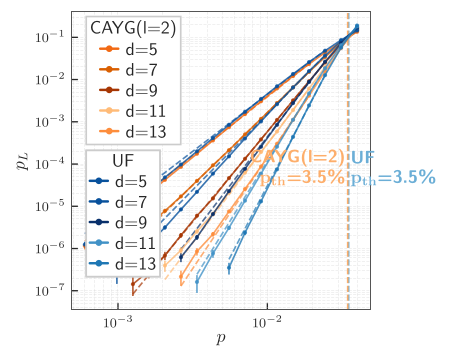

In [13]:
def collect_threshold_data(base_dirs, noise_model, decoders):
    data = collect_data(base_dirs, [], noise_models=[noise_model])

    data.results = data.results[data.results['decoder'].isin(decoders)]
    data.results = data.results[data.results['N'].isna()]
    data.results = data.results[data.results['l'] > 0]
    data.results = data.results[data.results['rounds'] == data.results['distance']]

    if data.results.empty:
        raise ValueError(f"No data for noise model {noise_model}")

    results = data.results.groupby(['decoder', 'distance']).apply(
        lambda x: x.set_index('p')[['l', 'n']]
        .apply(lambda row: (row['l'], row['n']), axis=1)
        .to_dict()
    )

    return results


def plot_threshold(ax, results,
                   plot_error_bars=False,
                   plot_fit=False,
                   plot_legend=True,
                   thresholds=None,
                   fit_margin=0.7):

    effective_distances = {}
    grouped_lines = {}

    for (decoder, distance), values in results.items():
        colors = decoder_colors(decoder, shift=False)
        label = decoder_name(decoder)

        ps = list(values.keys())
        ls, ns = zip(*(values.values()))

        ps = np.array(ps)
        ls = np.array(ls, dtype=float)
        ns = np.array([n if n is not None and not np.isnan(n) else 200000 for n in ns], dtype=float)

        idx = np.argsort(ps)
        ps, ls, ns = ps[idx], ls[idx], ns[idx]
        
        z = norm.ppf(1 - 0.05 / 2)  # z ≈ 1.96

        # Wilson interval
        center = (ls + z**2 / (2*ns)) / (1 + z**2 / ns)
        half_width = z * np.sqrt(ls*(1-ls)/ns + z**2/(4*ns**2)) / (1 + z**2/ns)

        upper = center + half_width
        lower = center - half_width

        # Asymmetric error bars relative to the point estimate (center)
        yerr_lower = np.clip(center - lower, 0, None)
        yerr_upper = np.clip(upper - center, 0, None)

        # Standard error for curve_fit
        sigma = half_width / z  # = sqrt(p(1-p)/n + ...) / (1 + z^2/n)
        sigma = np.clip(sigma, 1e-10, None)  # guard against zeros
        
        # Only keep points where errors are <= 0.5 of value
        mask = half_width <= 0.5 * center
        
        ps, center, yerr_lower, yerr_upper, sigma = ps[mask], center[mask], yerr_lower[mask], yerr_upper[mask], sigma[mask]

        # try:
        # Fit log(p_L) = b*log(p) + log(a), below threshold only
        p_thresh_fit = thresholds[decoder][0] if thresholds and decoder in thresholds else None
        # Keep only points well below threshold: near-threshold points deviate from
        # pure power-law scaling and bias the fitted exponent (verified empirically —
        # dropping the single closest-to-threshold point shifts d_eff by ~1, far more
        # than the fit's own statistical error).
        mask = (ps < fit_margin * p_thresh_fit) if p_thresh_fit is not None else np.ones(len(ps), dtype=bool)
        ps_fit, center_fit, sigma_fit = ps[mask], center[mask], sigma[mask]
        # Propagate errors for log-log fit:
        sigma_log = sigma_fit / center_fit  # d(log(y))/dy = 1/y
        if len(ps_fit) >= 2 and np.all(center_fit > 0):
            coeffs, cov = np.polyfit(np.log(ps_fit), np.log(center_fit), 1, w=1/sigma_log, cov=True)
            b_exp = coeffs[0]
            b_exp_err = np.sqrt(np.diag(cov)[0]) if len(np.diag(cov)) > 0 else 0
            effective_distance = abs(b_exp) * 2 - 1
            effective_distance_err = b_exp_err * 2 
            print(f"Decoder: {decoder}, Distance: {distance}, Effective distance: {effective_distance:.3f} ± {effective_distance_err:.3f}")
            effective_distances[(decoder, distance)] = (effective_distance, effective_distance_err)
            
            if plot_fit:
                p_fit = np.logspace(np.log10(min(ps_fit)), np.log10(max(ps_fit)), 100)
                ax.plot(p_fit, np.exp(coeffs[1]) * p_fit**b_exp,
                        '--', color=colors[distance % len(colors)],
                        linewidth=1, alpha=0.7)
        # except Exception:
        #     pass

        color = colors[distance % len(colors)]
        shortened_label = f"d={distance}"

        if plot_error_bars:
            line = ax.errorbar(ps, center, yerr=[yerr_lower, yerr_upper], fmt='o-',
                            color=color, markersize=1.5,
                            linewidth=1, alpha=0.8)
        else:
            line, = ax.plot(ps, center, 'o-',
                            color=color, markersize=1.5,
                            linewidth=1, alpha=0.8)

        grouped_lines.setdefault(label, []).append((line, shortened_label))

    # grouped legends
    if plot_legend:
        for i, (dec_name, entries) in enumerate(grouped_lines.items()):
            legend_elements = [
                Line2D([0], [0],
                    color=line.get_color() if not plot_error_bars else line.lines[0].get_color(),
                    lw=1.5, marker='o', label=lbl)
                for line, lbl in entries
            ]

            leg = ax.legend(handles=legend_elements,
                            title=dec_name,
                            loc='upper left',
                            bbox_to_anchor=(0.02, 1.015 - 0.45*i),
                            frameon=True,
                            fontsize='large',
                            handlelength=1.0,
                            handletextpad=0.4,
                            borderpad=0.2,
                            labelspacing=0.25,
                            title_fontsize='large')
            ax.add_artist(leg)

    # thresholds
    if thresholds:
        for decoder, (p_thresh, y_value, placement) in thresholds.items():
            color = decoder_colors(decoder, shift=False)[0]
            label = decoder_name(decoder)

            ax.axvline(x=p_thresh, color=color, linestyle='--', linewidth=1)

            if placement > 0:
                x_value = p_thresh * 1.03
                ha = 'left'
            else:
                x_value = p_thresh * 0.97
                ha = 'right'
            
            pth_text = r"$\mathbf{p_{th}}$" + f"={(p_thresh*100):.1f}%"
            
            ax.text(x_value, y_value,
                    f"{label}\n" + pth_text,
                    rotation=0,
                    ha=ha,
                    va='bottom',
                    fontsize='large',
                    fontweight='bold',
                    color=color)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r'$p$', fontsize='large')
    ax.set_ylabel(r'$p_L$', fontsize='large')
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)

    return effective_distances

base_dirs = [
    "../../data/threshold",
]

decoders = [
    'clayg_no_stop_early_lifetime_2.0_growth_rounds_1',
    'uf_no_stop_early',
]

noise_model = 'NORMAL_1.0_MEASUREMENT_0.1'

results = collect_threshold_data(base_dirs, noise_model, decoders)

# Plot threshold for NM NORMAL_1.0_MEASUREMENT_0.1
fig = plot_setup(aspect_ratio=1.0)
ax = fig.add_subplot(1, 1, 1)
effective_distances = plot_threshold(
    ax, results,
    plot_error_bars=True, plot_fit=True, plot_legend=True,
    thresholds={
        'uf_no_stop_early': (0.035, 3e-5, +1),
        'clayg_no_stop_early_lifetime_2.0_growth_rounds_1': (0.0345, 3e-5, -1),
    },
)
fig.savefig("threshold_plot.pdf", bbox_inches='tight')
fig

<>:129: SyntaxWarning: invalid escape sequence '\p'
<>:129: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_105372/3340544341.py:129: SyntaxWarning: invalid escape sequence '\p'
  row.append(f"{val:.2f} $\pm$ {err:.2f}" if val is not None else "--")
/tmp/ipykernel_105372/1150999731.py:237: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_105372/1150999731.py:266: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping colum

Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 5, Effective distance: 4.680 ± 0.027
Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 7, Effective distance: 6.305 ± 0.013
Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 9, Effective distance: 7.993 ± 0.015
Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 11, Effective distance: 9.178 ± 0.060
Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 13, Effective distance: 10.474 ± 0.085
Decoder: uf_no_stop_early, Distance: 5, Effective distance: 4.659 ± 0.030
Decoder: uf_no_stop_early, Distance: 7, Effective distance: 6.761 ± 0.032
Decoder: uf_no_stop_early, Distance: 9, Effective distance: 9.074 ± 0.032
Decoder: uf_no_stop_early, Distance: 11, Effective distance: 11.563 ± 0.030
Decoder: uf_no_stop_early, Distance: 13, Effective distance: 14.042 ± 0.023


/tmp/ipykernel_105372/1150999731.py:237: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_105372/1150999731.py:266: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_105372/836553154.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping c

Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 5, Effective distance: 4.614 ± 0.030
Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 7, Effective distance: 6.102 ± 0.014
Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 9, Effective distance: 7.806 ± 0.009
Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 11, Effective distance: 8.827 ± 0.072
Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 13, Effective distance: 10.053 ± 0.082
Decoder: uf_no_stop_early, Distance: 5, Effective distance: 4.520 ± 0.038
Decoder: uf_no_stop_early, Distance: 7, Effective distance: 6.489 ± 0.042
Decoder: uf_no_stop_early, Distance: 9, Effective distance: 8.673 ± 0.046
Decoder: uf_no_stop_early, Distance: 11, Effective distance: 10.985 ± 0.052
Decoder: uf_no_stop_early, Distance: 13, Effective distance: 13.309 ± 0.061


/tmp/ipykernel_105372/1150999731.py:237: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_105372/1150999731.py:266: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_105372/836553154.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping c

Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 5, Effective distance: 4.586 ± 0.030
Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 7, Effective distance: 5.886 ± 0.011
Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 9, Effective distance: 7.546 ± 0.015
Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 11, Effective distance: 8.369 ± 0.054
Decoder: clayg_no_stop_early_lifetime_2.0_growth_rounds_1, Distance: 13, Effective distance: 9.507 ± 0.075
Decoder: uf_no_stop_early, Distance: 5, Effective distance: 4.554 ± 0.033
Decoder: uf_no_stop_early, Distance: 7, Effective distance: 6.413 ± 0.039
Decoder: uf_no_stop_early, Distance: 9, Effective distance: 8.507 ± 0.042
Decoder: uf_no_stop_early, Distance: 11, Effective distance: 10.737 ± 0.037
Decoder: uf_no_stop_early, Distance: 13, Effective distance: 13.021 ± 0.063


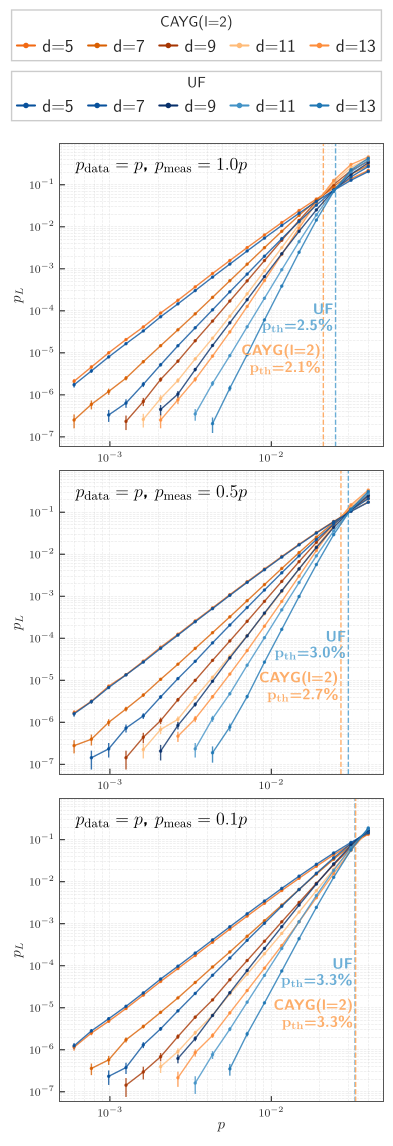

In [14]:
noise_models = {
    'NORMAL_1.0_MEASUREMENT_1.0': {
        'uf_no_stop_early': (0.025, 3e-5, -1),
        'clayg_no_stop_early_lifetime_2.0_growth_rounds_1': (0.021, 3e-6, -1),
    },
    'NORMAL_1.0_MEASUREMENT_0.5': {
        'uf_no_stop_early': (0.03, 3e-5, -1),
        'clayg_no_stop_early_lifetime_2.0_growth_rounds_1': (0.027, 3e-6, -1),
    },
    'NORMAL_1.0_MEASUREMENT_0.1': {
        'uf_no_stop_early': (0.033, 3e-5, -1),
        'clayg_no_stop_early_lifetime_2.0_growth_rounds_1': (0.0333, 3e-6, -1),
    },
}

fig, axes = plt.subplots(3, 1, figsize=(4, 12), sharey=True)
effective_distances_all = {}
all_line_handles = {}  # (decoder, distance) -> Line2D, built from last axis

for idx, (ax, (nm, thresholds)) in enumerate(zip(axes, noise_models.items())):
    results = collect_threshold_data(base_dirs, nm, decoders)
    effective_distances = plot_threshold(
        ax, results,
        plot_error_bars=True, plot_fit=False, plot_legend=False,
        thresholds=thresholds,
    )
    effective_distances_all[nm] = effective_distances
    
    # Place title inside the plot
    ax.text(0.05, 0.95, noise_model_name(nm), 
            transform=ax.transAxes, verticalalignment='top',
            fontsize='x-large', fontweight='bold', color='black')
    
    # Add x label only to the bottom plot
    if idx == len(axes) - 1:
        ax.set_xlabel(r'$p$', fontsize='large')
    else:
        ax.set_xlabel("")

    # Harvest line handles from this axis — overwrite each time,
    # last nm is fine since colors/markers are decoder+distance-determined
    for (decoder, distance) in effective_distances.keys():
        colors = decoder_colors(decoder, shift=False)
        color = colors[distance % len(colors)]
        all_line_handles[(decoder, distance)] = Line2D(
            [0], [0],
            color=color, lw=1.5,
            marker='o', markersize=3,
            label=f"d={distance}",
        )

# Group handles by decoder for one legend block per decoder
from collections import defaultdict
handles_by_decoder = defaultdict(list)
all_distances_legend = set()
for (decoder, distance), handle in sorted(
    all_line_handles.items(), key=lambda x: (x[0][0], x[0][1])
):
    handles_by_decoder[decoder].append((distance, handle))
    all_distances_legend.add(distance)

# Place one legend per decoder below the subplots
fig.tight_layout()
fig.subplots_adjust(bottom=0.05 + 0.07 * len(handles_by_decoder))

legend_y = 1.05
for decoder, dist_handles in handles_by_decoder.items():
    dist_handles_sorted = sorted(dist_handles, key=lambda x: x[0])
    handles = [h for _, h in dist_handles_sorted]
    leg = fig.legend(
        handles=handles,
        title=decoder_name(decoder),
        loc='lower center',
        bbox_to_anchor=(0.5, legend_y),
        ncol=len(handles),
        frameon=True,
        fontsize='x-large',
        title_fontsize='large',
        handlelength=1.0,
        handletextpad=0.4,
        borderpad=0.3,
        columnspacing=0.8,
    )
    legend_y -= 0.05  # stack legends vertically

plt.savefig("threshold_plot_comparison.pdf", bbox_inches='tight')

all_decoders_pretty = {}
all_distances = set()
for nm, eff_dist in effective_distances_all.items():
    for (decoder, distance), eff in eff_dist.items():
        all_decoders_pretty[decoder] = decoder_name(decoder)
        all_distances.add(distance)

unique_decoders = sorted(set(all_decoders_pretty.values()))
all_distances = sorted(all_distances)

with open("effective_distances_comparison.tex", "w") as f:
    n_dec = len(unique_decoders)
    f.write(r"\footnotesize" + "\n")
    f.write(r"\setlength{\tabcolsep}{4.5pt}" + "\n")
    f.write(r"\renewcommand{\arraystretch}{1.1}" + "\n")
    f.write(r"\begin{tabular}{|l|c" + "|c" * n_dec + "|}\n")
    f.write(r"\hline" + "\n")
    def fmt_header(dec):
        if "(" in dec:
            idx = dec.index("(")
            return r"\shortstack{" + dec[:idx].rstrip() + r"\\" + dec[idx:] + "}"
        return dec
    f.write("Noise Model & Distance & " + " & ".join(fmt_header(d) for d in unique_decoders) + r" \\" + "\n")
    f.write(r"\hline" + "\n")

    for nm, eff_dist in effective_distances_all.items():
        pivot = {}
        for (decoder, distance), (eff, eff_err) in eff_dist.items():
            pretty = all_decoders_pretty[decoder]
            pivot.setdefault(distance, {})[pretty] = (eff, eff_err)

        nm_raw = noise_model_name(nm)
        nm_label = r"\shortstack[l]{" + nm_raw.replace(", ", r",\\") + "}"
        for i, dist in enumerate(all_distances):
            nm_cell = (
                r"\multirow{" + str(len(all_distances)) + r"}{*}{" + nm_label + "}"
                if i == 0 else ""
            )
            row = [nm_cell, str(dist)]
            for dec in unique_decoders:
                val, err = pivot.get(dist, {}).get(dec, None)
                row.append(f"{val:.2f} $\pm$ {err:.2f}" if val is not None else "--")
            f.write(" & ".join(row) + r" \\" + "\n")
        f.write(r"\hline" + "\n")

    f.write(r"\end{tabular}" + "\n")
    f.write(r"\normalsize" + "\n")

fig

/tmp/ipykernel_105372/1150999731.py:237: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_105372/1150999731.py:266: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({
/tmp/ipykernel_105372/718367202.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping co

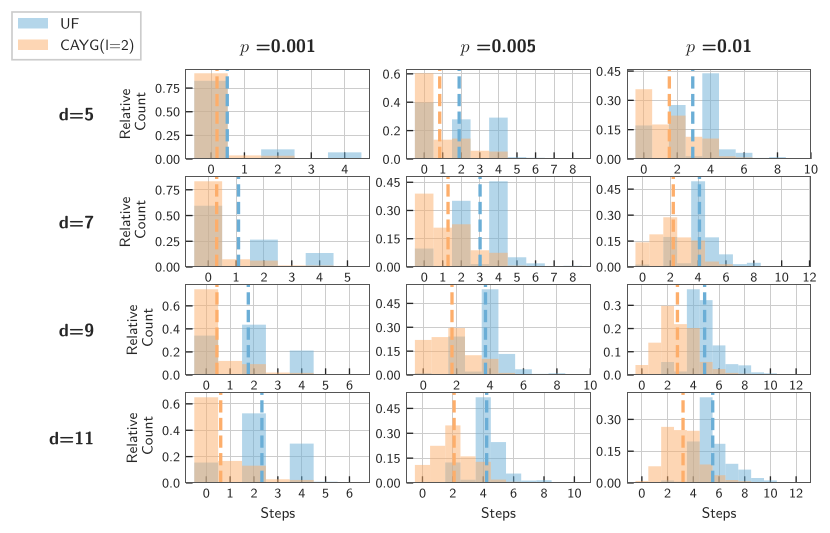

In [6]:
# Step distribution histograms

base_dirs = [
    "../../data/steps",
]

idling = collect_data(base_dirs, [], noise_models=True)

steps = idling.steps.groupby(['decoder', 'distance', 'p']).apply(lambda x: x.set_index('value')['occurences'].to_dict()).to_dict()

# Only keep steps with more than 100 occurences
steps = {k: {step: count for step, count in v.items() if count > 200} for k, v in steps.items()}

selected_decoders=['uf_no_stop_early', 'clayg_no_stop_early_lifetime_2.0_growth_rounds_1']
selected_distances=[5,7,9,11]
selected_ps=[0.001, 0.005, 0.01]

all_keys = list(steps.keys())
decoders = selected_decoders if selected_decoders else sorted({d for d, _, _ in all_keys})
distances = selected_distances if selected_distances else sorted({dist for _, dist, _ in all_keys})

all_ps = sorted({p for _, _, p in all_keys})
ps_to_plot = selected_ps if selected_ps else all_ps

n_rows = len(distances)
n_cols = len(ps_to_plot)

# Use plot_setup to create figure with correct aspect ratio
fig = plot_setup(aspect_ratio=0.5*n_rows/n_cols, width_ratio=1.0, wide=True)

axes = []
for i in range(n_rows):
    row_axes = []
    for j in range(n_cols):
        ax = fig.add_subplot(n_rows, n_cols, i*n_cols + j + 1)
        row_axes.append(ax)
    axes.append(row_axes)

for i, distance in enumerate(distances):
    for j, p in enumerate(ps_to_plot):
        ax = axes[i][j]
        for decoder in decoders:
            key = (decoder, distance, p)
            if key not in steps:
                continue
            counts = steps[key]
            x = []
            for step_val, count in counts.items():
                x.extend([step_val]*count)
            if not x:
                continue
            min_val, max_val = min(x), max(x)
            bins = np.arange(min_val, max_val + 2) - 0.5  # integer bins centered on step values

            color = decoder_colors(decoder, shift=False)[0]
            ax.hist(x, density=True, bins=bins, alpha=0.5, color=color, label=decoder_name(decoder), align='mid')
            # Plot vertical line for mean
            mean_val = np.mean(x)
            ax.axvline(mean_val, color=color, linestyle='dashed', linewidth=2)
        
        if j == 0:
            ax.set_ylabel(f"Relative\n Count")
        if i == n_rows-1:
            ax.set_xlabel("Steps")
        ax.grid(True)
        
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True, nbins=4))

# Add ps to top of each column
for j, p in enumerate(ps_to_plot):
    axes[0][j].text(0.5, 1.15, r"$p$ "f"={p}", transform=axes[0][j].transAxes,
                    fontsize='large', fontweight='bold', va='bottom', ha='center')

# Add distances to left side of each row
for i, distance in enumerate(distances):
    axes[i][0].text(-0.5, 0.5, f"d={distance}", transform=axes[i][0].transAxes,
                    fontsize='large', fontweight='bold', va='center', ha='right')

handles, labels = axes[0][0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(-.10, 1))
    

plt.savefig("steps_histograms.pdf", bbox_inches='tight')

fig

In [7]:
run = 'final_with_statistics/idling'
noise_model = 'NORMAL_1.0_MEASUREMENT_0.1'

base_dirs = [
    f"../../data/idling",
]

base_dirs += [base_dirs[0] + f"/shard_0{shard_idx}" for shard_idx in range(5)]

use_cached = True

if not use_cached:
    data = collect_data(base_dirs, [], noise_models=noise_model)
    # cache the results for future use
    cache_file = f"cached_data_{run.replace('/', '_')}_{noise_model}.pickle"
    with open(cache_file, 'wb') as f:
        pickle.dump(data, f)
else:
    cache_file = f"cached_data_{run.replace('/', '_')}_{noise_model}.pickle"
    if os.path.exists(cache_file):
        data = pd.read_pickle(cache_file)
        # If data.results doesnt have a column 'sum_sq', add it with NaN values
        if 'sum_sq' not in data.results.columns:
            data.results['sum_sq'] = np.nan
    else:
        data = collect_data(base_dirs, [], noise_models=noise_model)
        data.to_pickle(cache_file)

results = data.results
results = results[~(results['distance'] == 5)]

In [8]:
cache_file = f"cached_data_{run.replace('/', '_')}_{noise_model}.pickle"
idl = results[results.N.notna() & results.Np.notna()]
print("N_p :", results.Np.min(), "..", results.Np.max())
print("N_idl:", (idl.n/idl.Np).min(), "..", (idl.n/idl.Np).max())
results['distance'].unique()

N_p : 309270.0 .. 1000000.0
N_idl: 500.0 .. 500.0


array([ 7,  9, 11])

In [9]:
# Count rows per (decoder, distance, rounds) and report mean 'n' per group
grouped = results.groupby(['decoder', 'distance', 'rounds'], dropna=False)
counts = grouped.size().rename('rows')
mean_n = grouped['n'].mean()
stats = pd.concat([counts, mean_n], axis=1)

print(stats)
print("Minimum number of data points in any group:", stats['rows'].min())

                                                                  rows  \
decoder                                          distance rounds         
clayg_no_stop_early_lifetime_2.0_growth_rounds_1 7        7       2345   
                                                 9        9       2345   
                                                 11       11      2345   
uf_no_stop_early                                 7        7       2345   
                                                 9        9       2345   
                                                 11       11      2345   

                                                                             n  
decoder                                          distance rounds                
clayg_no_stop_early_lifetime_2.0_growth_rounds_1 7        7       3.510555e+08  
                                                 9        9       3.510554e+08  
                                                 11       11      3.510554e+08  
uf

Saved to pL_delta0.0_NORMAL_1.0_MEASUREMENT_0.1.gif
N=100.0 not in data, using closest N=100.063771 instead.


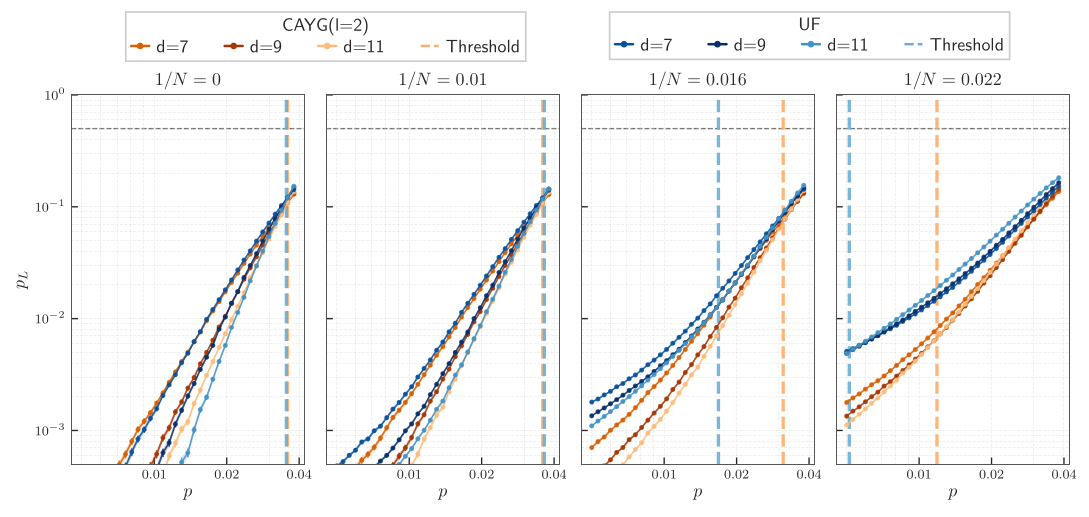

In [10]:
def wilson_center_and_error(l, n, confidence=0.95):
    z = norm.ppf(1 - (1 - confidence) / 2)  # z ≈ 1.96
    l = np.asarray(l, dtype=float)
    n = np.asarray(n, dtype=float)
    center = (l + z**2 / (2 * n)) / (1 + z**2 / n)
    half_width = z * np.sqrt(l * (1 - l) / n + z**2 / (4 * n**2)) / (1 + z**2 / n)
    return center, half_width


def get_baseline_n(nm_data, dec, dist, T_rounds, p_values, fallback_n):
    # Idling rows pool Np independent histories with Nidling correlated repeats each
    # (same recovery, only the injected idling noise differs), so naive Wilson on the
    # pooled n badly understates the true uncertainty. Use Np (the no-idling shot count
    # for the same p) as a conservative stand-in instead.
    baseline = nm_data[
        (nm_data['decoder'] == dec) &
        (nm_data['distance'] == dist) &
        (nm_data['rounds'] == T_rounds) &
        (nm_data['N'].isna())
    ][['p', 'n']].drop_duplicates('p')

    merged = pd.DataFrame({'p': np.asarray(p_values)}).merge(baseline, on='p', how='left')
    n_eff = merged['n'].to_numpy(dtype=float)
    fallback_n = np.asarray(fallback_n, dtype=float)
    missing = np.isnan(n_eff)
    n_eff[missing] = fallback_n[missing]
    return n_eff


def get_effective_n(l, n, sum_sq, Np):
    # Clustered-variance effective sample size: Np independent decoded histories,
    # each contributing Nidling correlated idling repeats. s2 is the sample variance
    # of the per-history failure rates (recovered from sum(X_i^2) via the sum-of-squares
    # identity); n_eff is the n a plain Wilson interval would need to match Var(p_L)=s2/Np.
    l, n, sum_sq, Np = (np.asarray(a, dtype=float) for a in (l, n, sum_sq, Np))
    Nidling = n / Np
    with np.errstate(invalid='ignore', divide='ignore'):
        s2 = (sum_sq / Nidling**2 - Np * l**2) / (Np - 1)
        n_eff = l * (1 - l) * Np / s2

    invalid = ~np.isfinite(n_eff) | (s2 <= 0)  # missing sum_sq (old data), or no detectable clustering
    n_eff = np.where(invalid, Np, n_eff)        # fall back to the Np-only stopgap
    return np.clip(n_eff, Np, n)                # true n_eff can't be below Np or above pooled n


def plot_pL(results, T_rounds_delta=1.0, N_values_plot=[np.nan, 50.539004, 1/0.05]):
    noise_models = results['noise_model'].unique()

    decoders  = results['decoder'].unique()
    distances = sorted(results['distance'].unique())
    
    for nm in noise_models:
        nm_data = results[results['noise_model'] == nm]

        fig = plot_setup(aspect_ratio=0.4, width_ratio=1.5, wide=True)
        axes = fig.subplots(1, len(N_values_plot), sharey=True)
        if len(N_values_plot) == 1:
            axes = [axes]

        grouped_lines = {}
        seen_thresholds = {}

        for ax, N in zip(axes, N_values_plot):
            mask_N = nm_data['N'].isna() if np.isnan(N) else (nm_data['N'] == N)
            sub = nm_data[mask_N]            
            for dec in decoders:
                colors    = decoder_colors(dec, shift=False)
                dec_label = decoder_name(dec)

                curves = {}
                
                for dist in distances:
                    T_rounds = np.ceil(dist * (1 + T_rounds_delta))
                    mask = (
                        (sub['decoder']  == dec) &
                        (sub['distance'] == dist) &
                        (sub['rounds']   == T_rounds)
                    )
                    pts = sub[mask].sort_values('p')
                    if pts.empty:
                        continue

                    color = colors[dist % len(colors)]

                    curves[dist] = pts

                    n_eff = get_effective_n(pts['l'], pts['n'], pts['sum_sq'], pts['Np'])
                    center, half_width = wilson_center_and_error(pts['l'], n_eff)
                    
                    line,_, _ = ax.errorbar(
                        pts['p'], pts['l'],
                        yerr=half_width,
                        fmt='o-',
                        color=color,
                        markersize=2,
                        linewidth=1,
                        alpha=0.85,
                    )
                    ax.fill_between(
                        pts['p'],
                        pts['l'] - half_width,
                        pts['l'] + half_width,
                        color=color,
                        alpha=0.2,
                        linewidth=0,
                    )
                    grouped_lines.setdefault(dec_label, []).append(
                        (line, f'd={dist}')
                    )
                # ----------------------------------
                # Threshold estimate for this decoder
                # ----------------------------------

                crossings = []

                dists = sorted(curves.keys())

                for d1, d2 in zip(dists[:-1], dists[1:]):
                    pts1 = curves[d1]
                    pts2 = curves[d2]

                    p1 = pts1['p'].to_numpy()
                    l1 = pts1['l'].to_numpy()

                    p2 = pts2['p'].to_numpy()
                    l2 = pts2['l'].to_numpy()

                    common_p = np.intersect1d(p1, p2)

                    if len(common_p) < 2:
                        continue

                    y1 = np.interp(common_p, p1, l1)
                    y2 = np.interp(common_p, p2, l2)

                    diff = y1 - y2

                    sign_changes = np.where(
                        np.sign(diff[:-1]) != np.sign(diff[1:])
                    )[0]

                    for idx in sign_changes:
                        x0 = common_p[idx]
                        x1 = common_p[idx + 1]

                        y0 = diff[idx]
                        y1_ = diff[idx + 1]

                        if np.isclose(y1_, y0):
                            continue

                        p_cross = x0 - y0 * (x1 - x0) / (y1_ - y0)
                        crossings.append(p_cross)
            
            
                if crossings:
                    p_th = np.min(crossings)
                    color = colors[0]
                    ax.axvline(
                        p_th,
                        color=color,
                        linestyle='--',
                        linewidth=2,
                        alpha=0.9,
                    )
                    seen_thresholds[dec_label] = color
                    
            ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8,
                       alpha=0.6, zorder=0)
            ax.set_title(
                f'$1/N = {1/N:.2g}$' if not np.isnan(N) else '$1/N = 0$',
                fontsize='large',
            )
            ax.set_xlabel(r'$p$', fontsize='large')
            ax.set_xscale('log')
            ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1.0, 2.0, 4.0), numticks=12))
            ax.xaxis.set_minor_formatter(NullFormatter())
            ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f'${v:g}$'))
            ax.set_yscale('log')
            ax.set_ybound(5e-4, 1.0)
            ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.3)

        axes[0].set_ylabel(r'$p_L$', fontsize='large')
        axes

        # Build one legend per decoder from all panels, deduplicating by label
        handles_by_decoder = {}
        for dec_label, entries in grouped_lines.items():
            seen = {}
            for line, d_label in entries:
                if d_label not in seen:
                    seen[d_label] = line
            handles_by_decoder[dec_label] = [
                Line2D([0], [0], color=line.get_color(), lw=1.5,
                       marker='o', markersize=3, label=lbl)
                for lbl, line in seen.items()
            ]
            if dec_label in seen_thresholds:
                color = seen_thresholds[dec_label]
                handles_by_decoder[dec_label].append(Line2D([0], [0], color=color, lw=1.5, linestyle='--', label='Threshold'))

        # Place title and legends side by side in the suptitle row
        fig.tight_layout()
        right_margin = 1 - 0.15 * (3 / len(N_values_plot))
        plt.subplots_adjust(right=right_margin, top=0.88)


        legend_x = 0.1
        for i, (dec_label, legend_elements) in enumerate(handles_by_decoder.items()):
            fig.legend(
                handles=legend_elements,
                title=dec_label,
                loc='upper left',
                bbox_to_anchor=(legend_x + i * 0.4, 1.07),
                frameon=True,
                fontsize='large',
                handlelength=1.0,
                handletextpad=0.4,
                borderpad=0.3,
                labelspacing=0.25,
                title_fontsize='large',
                ncol=len(legend_elements),
            )

        plt.savefig(f'pL_delta{T_rounds_delta}_{nm}.pdf', bbox_inches='tight')

    return fig


def save_pL_gif(results, T_rounds_delta=1.0, output_path='pL.gif', fps=1):
    thresholds = {}
    for nm in results['noise_model'].unique():
        nm_data = results[results['noise_model'] == nm]

        N_values_all = sorted(nm_data['N'].dropna().unique())[::-1]
        N_values_all = [N for N in N_values_all if N <= 150]
        if nm_data['N'].isna().any():
            N_values_all = [np.nan] + N_values_all

        decoders  = results['decoder'].unique()
        distances = sorted(results['distance'].unique())

        fig = plot_setup(aspect_ratio=0.7, width_ratio=1.3, wide=False)
        ax  = fig.add_subplot(1, 1, 1)

        def render(N):
            ax.cla()
            mask_N = nm_data['N'].isna() if (isinstance(N, float) and np.isnan(N)) else (nm_data['N'] == N)
            sub = nm_data[mask_N]
            grouped_lines = {}

            for dec in decoders:
                colors = decoder_colors(dec, shift=False)
                dec_label = decoder_name(dec)

                grouped_lines.setdefault(dec_label, [])

                curves = {}

                for dist in distances:
                    T_rounds = np.ceil(dist * (1 + T_rounds_delta))
                    mask = (
                        (sub['decoder'] == dec)
                        & (sub['distance'] == dist)
                        & (sub['rounds'] == T_rounds)
                    )

                    pts = sub[mask].sort_values('p')
                    if pts.empty:
                        continue

                    curves[dist] = pts

                    color = colors[dist % len(colors)]

                    n_eff = get_effective_n(pts['l'], pts['n'], pts['sum_sq'], pts['Np'])
                    center, half_width = wilson_center_and_error(pts['l'], n_eff)

                    line, = ax.plot(
                        pts['p'],
                        center,
                        'o-',
                        color=color,
                        markersize=2,
                        linewidth=1,
                        alpha=0.85,
                    )
                    ax.fill_between(
                        pts['p'],
                        center - half_width,
                        center + half_width,
                        color=color,
                        alpha=0.2,
                        linewidth=0,
                    )

                    grouped_lines[dec_label].append(
                        (line, f'd={dist}, T={T_rounds}')
                    )

                # ----------------------------------
                # Threshold estimate for this decoder
                # ----------------------------------

                crossings = []

                dists = sorted(curves.keys())

                for d1, d2 in zip(dists[:-1], dists[1:]):
                    pts1 = curves[d1]
                    pts2 = curves[d2]

                    p1 = pts1['p'].to_numpy()
                    l1 = pts1['l'].to_numpy()

                    p2 = pts2['p'].to_numpy()
                    l2 = pts2['l'].to_numpy()

                    common_p = np.intersect1d(p1, p2)

                    if len(common_p) < 2:
                        continue

                    y1 = np.interp(common_p, p1, l1)
                    y2 = np.interp(common_p, p2, l2)

                    diff = y1 - y2

                    sign_changes = np.where(
                        np.sign(diff[:-1]) != np.sign(diff[1:])
                    )[0]

                    for idx in sign_changes:
                        x0 = common_p[idx]
                        x1 = common_p[idx + 1]

                        y0 = diff[idx]
                        y1_ = diff[idx + 1]

                        if np.isclose(y1_, y0):
                            continue

                        p_cross = x0 - y0 * (x1 - x0) / (y1_ - y0)
                        crossings.append(p_cross)

                if crossings:
                    p_th = np.min(crossings)
                    
                    thresholds[(noise_model, dec_label, N)] = p_th

                    threshold_color = colors[0]

                    ax.axvline(
                        p_th,
                        color=threshold_color,
                        linestyle='--',
                        linewidth=2,
                        alpha=0.9,
                    )

                    ax.text(
                        p_th,
                        5e-5,
                        f'{dec_label}\n$p_{{th}}={p_th:.4f}$',
                        color=threshold_color,
                        rotation=90,
                        fontsize='x-small',
                        ha='right',
                        va='bottom',
                    )

            ax.axhline(0.5, color='black', linestyle='--', linewidth=0.8,
                    alpha=0.6, zorder=0)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_ybound(5e-5, 1.0)
            ax.set_xlabel(r'$p$')
            ax.set_ylabel(r'$p_L$')
            N_str = 'NaN' if (isinstance(N, float) and np.isnan(N)) else str(N)
            ax.set_title(
                f'{nm}  |  $T=d\\cdot(1+{T_rounds_delta})$,  $N={N_str}$',
                fontsize='small',
            )
            ax.grid(True, which='both', linestyle='--', linewidth=0.5)

            for i, (dec_label, entries) in enumerate(grouped_lines.items()):
                seen = {}
                for line, d_label in entries:
                    if d_label not in seen:
                        seen[d_label] = line
                legend_elements = [
                    Line2D([0], [0], color=l.get_color(), lw=1.5,
                        marker='o', markersize=3, label=lbl)
                    for lbl, l in seen.items()
                ]
                leg = ax.legend(
                    handles=legend_elements,
                    title=dec_label,
                    loc='upper left',
                    bbox_to_anchor=(0.01, 1.0 - 0.45 * i),
                    frameon=True, fontsize='medium',
                    handlelength=1.0, handletextpad=0.4,
                    borderpad=0.2, labelspacing=0.25,
                    title_fontsize='medium',
                )
                ax.add_artist(leg)

        ani = animation.FuncAnimation(
            fig,
            lambda i: render(N_values_all[i]),
            frames=len(N_values_all),
            repeat=True,
        )
        ani.save(output_path, writer='pillow', fps=fps)
        print(f"Saved to {output_path}")
        plt.close(fig)

    return thresholds

# --- call sites ---
T_rounds_delta = .0

thresholds = save_pL_gif(
    results,
    T_rounds_delta=T_rounds_delta,
    output_path=f'pL_delta{T_rounds_delta}_{noise_model}.gif',
    fps=2,
)

threshold_targets = [2e-2, 1e-3]
threshold_decoder = "UF"
thresholds_current_values = {}
for (nm, dec_label, N), p_th in thresholds.items():
    if dec_label == threshold_decoder:
        for target in threshold_targets:
            if not target in thresholds_current_values or abs(p_th - target) < abs(thresholds_current_values[target][1] - target):
                thresholds_current_values[target] = (N, p_th)

N_values_plot = [np.nan, 1/0.01] + [N for target, (N, p_th) in thresholds_current_values.items()]

# for each N in N_values plot if it doesnt exist in the data, take the closest N value
for i, N in enumerate(N_values_plot):
    if N not in results['N'].values and not np.isnan(N):
        closest_N = min(results['N'].dropna().unique(), key=lambda x: abs(x - N))
        print(f"N={N} not in data, using closest N={closest_N} instead.")
        N_values_plot[i] = closest_N

fig = plot_pL(results, T_rounds_delta, N_values_plot=N_values_plot)

fig

Plotting advantage regions for p_L...


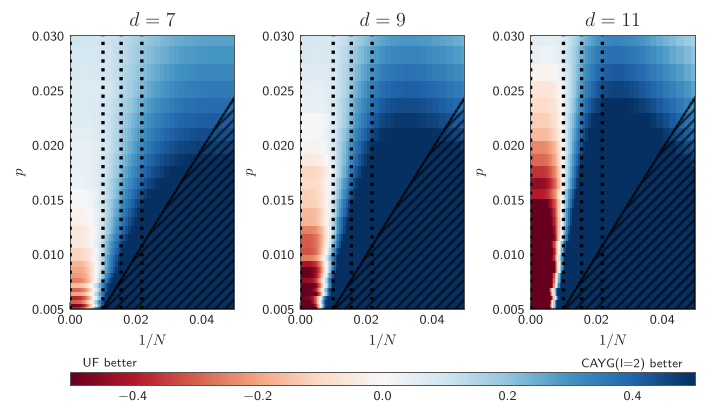

In [11]:
# Advantage region wrt p_L (direct), for a fixed number of rounds T
# Regions where p_L >= 1/2 for either decoder are overlaid

decoder_a = 'uf_no_stop_early'
decoder_b = 'clayg_no_stop_early_lifetime_2.0_growth_rounds_1'
inv_N_range = (0.0, 0.05)
p_range    = (0.005, 0.03)

T_rounds_delta = 0
noise_model = 'NORMAL_1.0_MEASUREMENT_0.1'     

plot_advantage_threshold = False

# -----------------------------------------------------------

data_pL = results[
    (results['noise_model'] == noise_model) &
    (results['rounds'] == (results['distance']*(1+T_rounds_delta)).astype(int))
].copy()

data_pL['inv_N'] = (1 / data_pL['N']).fillna(0)

distances = sorted(data_pL['distance'].unique())

os.makedirs(f"../paper/figures/pL_advantage_plots_run_{run}/", exist_ok=True)

print("Plotting advantage regions for p_L...")
fig = plot_setup(aspect_ratio=4/7, width_ratio=1.0, wide=True)
axes = []

cols = min(3, len(distances))
rows = int(np.ceil(len(distances) / cols))

color_norm = Normalize(vmin=-0.5, vmax=0.5)
cmap = plt.get_cmap('RdBu')

for idx, distance in enumerate(distances):
    T_rounds = int(distance*(1+T_rounds_delta))
    ax = fig.add_subplot(rows, cols, idx + 1)
    ax.set_title(f"$d = {distance}$")
    axes.append(ax)

    df_d = data_pL[data_pL['distance'] == distance]
    df_a = df_d[df_d['decoder'] == decoder_a]
    df_b = df_d[df_d['decoder'] == decoder_b]

    if df_a.empty or df_b.empty:
        continue

    # ---------------------------------------------------
    # merge on shared (p, N) grid
    # ---------------------------------------------------

    merged = pd.merge(
        df_a[['p', 'N', 'inv_N', 'l']],
        df_b[['p', 'N', 'l']],
        on=['p', 'N'],
        suffixes=('_a', '_b'),
    )

    merged = merged[
        (merged['inv_N'] >= inv_N_range[0]) &
        (merged['inv_N'] <= inv_N_range[1]) &
        (merged['p']     >= p_range[0]) &
        (merged['p']     <= p_range[1])
    ]

    if merged.empty:
        continue

    # relative difference in p_L:  (a − b) / <a, b>
    merged['rel_diff'] = (
        (merged['l_a'] - merged['l_b']) /
        (0.5 * (merged['l_a'] + merged['l_b']))
    )

    # ---------------------------------------------------
    # pivot tables
    # ---------------------------------------------------

    pivot      = merged.pivot_table(index='p', columns='inv_N', values='rel_diff').sort_index()

    inv_N_coords = pivot.columns.values
    p_coords     = pivot.index.values

    # ---------------------------------------------------
    # main heatmap
    # ---------------------------------------------------

    im = ax.pcolormesh(
        inv_N_coords, p_coords, pivot.values,
        cmap=cmap, shading='auto', norm=color_norm,
        rasterized=True,
    )
    

    # physical-regime boundary (same as before)
    unphysical_k = 1
    inv_N_fine  = np.linspace(inv_N_range[0] + 1e-6, inv_N_range[1], 300)
    p_boundary  = 0.5 * (1 - np.exp(-unphysical_k*inv_N_fine))
    ax.plot(inv_N_fine, p_boundary, color='black', lw=1.0, ls=':', zorder=5)
    # fill the unphysical region with a hatch
    verts_x = np.concatenate([inv_N_fine, inv_N_fine[::-1]])
    verts_y = np.concatenate([p_boundary, np.full_like(inv_N_fine, p_range[0])])
    mask = verts_y >= p_range[0]
    poly = Polygon(
        np.column_stack([verts_x, verts_y]),
        closed=True, facecolor='none', edgecolor='black',
        linewidth=1.5, hatch='////', alpha=0.6, zorder=1,
    )
    ax.add_patch(poly)

    # vertical lines at chosen N values
    for N_val in N_values_plot:
        inv_N_val = 0.0 if np.isnan(N_val) else 1.0 / N_val
        if inv_N_range[0] <= inv_N_val <= inv_N_range[1]:
            ax.axvline(x=inv_N_val, color='black', ls=':', lw=2.0, zorder=3)

    ax.set_xlim(inv_N_range)
    ax.set_ylim(p_range)
    ax.set_xlabel(r"$1/N$")
    ax.set_ylabel(r"$p$")

# -------------------------------------------------------
# layout & colorbar
# -------------------------------------------------------

plt.subplots_adjust(hspace=0.6, wspace=0.4)

decoder_a_name = decoder_name(decoder_a)
decoder_b_name = decoder_name(decoder_b)

cbar = fig.colorbar(
    cm.ScalarMappable(norm=color_norm, cmap=cmap),
    ax=axes,
    orientation='horizontal',
    location='bottom',
    fraction=0.05,   # thickness of the bar relative to axes
    pad=0.18,        # gap between plots and colorbar
    aspect=50,       # length-to-thickness ratio
)

cbar.ax.text(0.02, 2.2, f"{decoder_a_name} better",
                va='top', ha='left', fontsize='small', rotation=0,
                transform=cbar.ax.transAxes)
cbar.ax.text(0.98, 2.2, f"{decoder_b_name} better",
                va='top', ha='right', fontsize='small', rotation=0,
                transform=cbar.ax.transAxes)

plt.savefig(
    f"pL_advantage.pdf",
    bbox_inches='tight',
)

fig

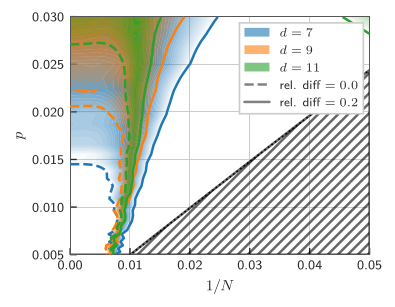

In [14]:
# Advantage region wrt p_L (direct), overlaid across distances in different colors
from matplotlib.colors import LinearSegmentedColormap

decoder_a = 'uf_no_stop_early'
decoder_b = 'clayg_no_stop_early_lifetime_2.0_growth_rounds_1'

inv_N_range = (0.0, 0.05)
p_range     = (0.005, 0.03)
T_rounds_delta = 0

noise_model = 'NORMAL_1.0_MEASUREMENT_0.1'
plot_advantage_threshold = False
plot_threshold_plot_lines = False

# --- interval defining the "boundary region" to overlay ---
rel_diff_band = (0.00, 0.2)   

data_pL = results[
    (results['noise_model'] == noise_model) &
    (results['rounds'] == (results['distance'] * (1 + T_rounds_delta)).astype(int))
].copy()
data_pL['inv_N'] = (1 / data_pL['N']).fillna(0)
distances = sorted(data_pL['distance'].unique())

os.makedirs(f"../paper/figures/pL_advantage_plots_run_{run}/", exist_ok=True)

# one color per distance, perceptually distinct
dist_cmap   = plt.get_cmap('tab10')
dist_colors = {d: dist_cmap(i % 10) for i, d in enumerate(distances)}

fig = plot_setup(aspect_ratio=4/5, width_ratio=1.0, wide=False)
ax  = fig.add_subplot(1, 1, 1)

legend_handles = []

for distance in distances:
    T_rounds = int(distance * (1 + T_rounds_delta))
    df_d = data_pL[data_pL['distance'] == distance]
    df_a = df_d[df_d['decoder'] == decoder_a]
    df_b = df_d[df_d['decoder'] == decoder_b]

    if df_a.empty or df_b.empty:
        continue

    # merge on shared (p, N) grid
    merged = pd.merge(
        df_a[['p', 'N', 'inv_N', 'l']],
        df_b[['p', 'N', 'l']],
        on=['p', 'N'],
        suffixes=('_a', '_b'),
    )
    merged = merged[
        (merged['inv_N'] >= inv_N_range[0]) &
        (merged['inv_N'] <= inv_N_range[1]) &
        (merged['p']     >= p_range[0]) &
        (merged['p']     <= p_range[1])
    ]
    if merged.empty:
        continue

    merged['rel_diff'] = (
        (merged['l_a'] - merged['l_b']) /
        (0.5 * (merged['l_a'] + merged['l_b']))
    )

    # pivot
    pivot        = merged.pivot_table(index='p', columns='inv_N', values='rel_diff').sort_index()
    inv_N_coords = pivot.columns.values
    p_coords     = pivot.index.values
    Z            = pivot.values

    color = dist_colors[distance]

    # --- filled contour band: rel_diff in [band_lo, band_hi] ---
    # contourf with two levels brackets the band
    color = dist_colors[distance]
    lo, hi = rel_diff_band
    mid = (lo + hi) / 2.0   # or hardcode 0.0 if zero is inside the band

    # Build a colormap: transparent at lo, opaque distance-color at hi
    r, g, b, _ = color
    dist_cmap_local = LinearSegmentedColormap.from_list(
        f"dist_{distance}",
        [
            (r, g, b, 0.0),   # opaque at lo
            (r, g, b, 1.0),   # transparent at midpoint
            (r, g, b, 0.0),   # opaque at hi
        ],
        N=256,
    )
    # Mask values outside [lo, hi]
    Z_masked = np.ma.masked_outside(Z, lo, hi)
    
    # 1. Smooth Z slightly to kill single-point spikes
    #    sigma=1 is mild; increase to 1.5–2 if arms persist
    from scipy.ndimage import gaussian_filter, label
    Z_smooth = Z # gaussian_filter(Z, sigma=0.8, mode='nearest')

    # Filled gradient inside the band
    try:
        ax.contourf(
            inv_N_coords, p_coords, Z_smooth,
            levels=np.linspace(lo, hi, 50),
            cmap=dist_cmap_local,
            norm=Normalize(vmin=lo, vmax=hi),
            zorder=2,
        )
    except Exception:
        print(f"Warning: contourf failed for distance {distance}")
        pass

    # Boundary contour lines at band edges
    for level, ls in [(lo, '--'), (hi, '-')]:
        try:
            ax.contour(
                inv_N_coords, p_coords, Z_smooth,
                levels=[level],
                colors=[color],
                linewidths=1.5,
                linestyles=ls,
                zorder=3,
            )
        except Exception:
            print(f"Warning: contour failed for distance {distance} at level {level}")
            pass

    legend_handles.append(
        Patch(facecolor=color, alpha=0.6, label=f"$d = {distance}$")
    )

# -----------------------------------------------------------
# physical-regime boundary  p = ½(1 − e^{−1/N})
# -----------------------------------------------------------
inv_N_fine = np.linspace(inv_N_range[0] + 1e-6, inv_N_range[1], 300)
p_boundary = 0.5 * (1 - np.exp(-inv_N_fine))
ax.plot(inv_N_fine, p_boundary, color='black', lw=1.0, ls=':', zorder=5)

verts_x = np.concatenate([inv_N_fine, inv_N_fine[::-1]])
verts_y = np.concatenate([p_boundary, np.full_like(inv_N_fine, p_range[0])])
poly = Polygon(
    np.column_stack([verts_x, verts_y]),
    closed=True, facecolor='none', edgecolor='black',
    linewidth=1.5, hatch='////', alpha=0.6, zorder=1,
)
ax.add_patch(poly)

if plot_threshold_plot_lines:
    # vertical lines at chosen N values
    for N_val in N_values_plot:
        inv_N_val = 0.0 if np.isnan(N_val) else 1.0 / N_val
        if inv_N_range[0] <= inv_N_val <= inv_N_range[1]:
            ax.axvline(x=inv_N_val, color='black', ls=':', lw=2.0, zorder=3)

ax.set_xlim(inv_N_range)
ax.set_ylim(p_range)
ax.set_xlabel(r"$1/N$")
ax.set_ylabel(r"$p$")

# --- custom legend lines for band edges ---
band_lo_line = Line2D([], [], color='grey', ls='--', lw=1.5,
                                label=f"rel. diff $= {rel_diff_band[0]}$")
band_hi_line = Line2D([], [], color='grey', ls='-',  lw=1.5,
                                label=f"rel. diff $= {rel_diff_band[1]}$")
legend_handles += [band_lo_line, band_hi_line]

ax.legend(handles=legend_handles, fontsize='small',
            loc='upper right')

decoder_a_name      = decoder_name(decoder_a)
decoder_b_name      = decoder_name(decoder_b)

plt.savefig(
    f"pL_boundary_overlay.pdf",
    bbox_inches='tight',
)
fig